# Thinning vs thinning + MAGNET — ensemble comparison

Side-by-side analysis of two continuation-ensemble runs from
`runnable_code/catalog_california_continuation_ensemble.py`:

- **Ogata thinning** (`simulate_magnitudes`)
- **Ogata thinning + MAGNET** (`MAGNET_magnitude`)

Each method writes per-realization `forecast_catalog.csv` under::

  outputs/catalog_etas_vs_thinning/ensembles/<method>/inv_<id>/seed_<seed>/

This notebook mirrors the Tier 1 / Tier 2 / formal-test workflow in
`load_etas_vs_thinning_ensemble_realizations.ipynb`, but compares the two
thinning variants on **matched seeds**.

In [1]:
%matplotlib inline
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy import stats
from shapely.geometry import Polygon

THINNING_COLOR = "indianred"
MAGNET_COLOR = "royalblue"
METHOD_A_LABEL = "Thinning"
METHOD_B_LABEL = "Thinning + MAGNET"


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


In [2]:
def find_repo_root() -> Path:
    for start in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (start / "runnable_code" / "catalog_california_continuation_ensemble.py").is_file():
            return start
        if start.name == "notebooks" and (start.parent / "runnable_code").is_dir():
            return start.parent
    raise FileNotFoundError(
        "Could not find etas repo root. Set the kernel cwd to the repo or notebooks/ folder."
    )


REPO_ROOT = find_repo_root()

# Optional sibling checkout for ETAS inversion imports.
for _candidate in [
    REPO_ROOT.parent / "eq_mag_prediction/eq_mag_prediction_clean",
    REPO_ROOT.parent / "eq_mag_prediction",
]:
    if (_candidate / "eq_mag_prediction").is_dir() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

RUN_OUTPUTS_ROOT = REPO_ROOT / "outputs/hauksson_catalog_etas_vs_thinning"
ENSEMBLES_ROOT = RUN_OUTPUTS_ROOT / "ensembles"
THINNING_ENSEMBLE_DIR = ENSEMBLES_ROOT / "thinning/inv_fde4667b33a3b02a"
MAGNET_ENSEMBLE_DIR = ENSEMBLES_ROOT / "thinning_magnet/inv_fde4667b33a3b02a"

LOAD_MODE: Literal["all", "first_n", "seeds"] = "all"
FIRST_N: int = 5
SEEDS: list[int] = [0, 1, 2, 3, 4]


In [3]:
CONTINUATION_METHODS = ("thinning", "thinning_magnet")
_FORECAST_CATALOG_NAME = "forecast_catalog.csv"


def list_method_ensemble_dirs(method: str, ensembles_root: Path) -> list[Path]:
    method_root = ensembles_root / method
    if not method_root.is_dir():
        return []
    found: list[Path] = []
    for path in method_root.iterdir():
        if path.is_dir() and path.name.startswith("inv_"):
            try:
                discover_realization_seeds(path)
            except FileNotFoundError:
                continue
            found.append(path)
    return sorted(found, key=lambda p: p.stat().st_mtime, reverse=True)


def resolve_method_ensemble_dir(
    explicit: Path | None,
    method: str,
    ensembles_root: Path,
) -> Path:
    if explicit is not None:
        path = explicit.expanduser()
        if not path.is_absolute():
            path = (REPO_ROOT / path).resolve()
        else:
            path = path.resolve()
        if path.is_dir():
            return path
    candidates = list_method_ensemble_dirs(method, ensembles_root)
    if explicit is not None:
        raise FileNotFoundError(f"Ensemble directory not found for {method}: {explicit}")
    if not candidates:
        raise FileNotFoundError(
            f"No {method} ensemble under {ensembles_root / method}. "
            "Run catalog_california_continuation_ensemble.py --method "
            f"{method} first."
        )
    chosen = candidates[0]
    print(f"Auto-selected {method} ensemble: {chosen}")
    return chosen


def discover_realization_seeds(ensemble_dir: Path) -> list[int]:
    seeds: set[int] = set()
    for path in ensemble_dir.iterdir():
        if path.is_dir() and path.name.startswith("seed_"):
            seeds.add(int(path.name.removeprefix("seed_")))
    legacy = ensemble_dir / "realizations"
    if legacy.is_dir():
        for path in legacy.iterdir():
            if path.is_dir() and path.name.startswith("seed_"):
                seeds.add(int(path.name.removeprefix("seed_")))
    if not seeds:
        raise FileNotFoundError(f"No seed_* folders under {ensemble_dir}")
    return sorted(seeds)


def select_seeds(
    available: list[int],
    *,
    mode: Literal["all", "first_n", "seeds"],
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> list[int]:
    if mode == "all":
        return list(available)
    if mode == "first_n":
        if first_n is None or first_n < 1:
            raise ValueError("first_n must be >= 1")
        return available[:first_n]
    if mode == "seeds":
        if not seeds:
            raise ValueError("SEEDS must be non-empty")
        missing = sorted(set(seeds) - set(available))
        if missing:
            raise ValueError(f"Requested seeds not found: {missing}; available: {available}")
        return [s for s in available if s in set(seeds)]
    raise ValueError(f"Unknown mode: {mode!r}")


def _realization_dir_for_seed(ensemble_dir: Path, seed: int) -> Path:
    flat = ensemble_dir / f"seed_{seed}"
    legacy = ensemble_dir / "realizations" / f"seed_{seed}"
    if flat.is_dir():
        return flat
    if legacy.is_dir():
        return legacy
    return flat


def load_forecast_catalog(ensemble_dir: Path, seed: int) -> pd.DataFrame:
    path = _realization_dir_for_seed(ensemble_dir, seed) / _FORECAST_CATALOG_NAME
    if not path.is_file():
        raise FileNotFoundError(path)
    catalog = pd.read_csv(path)
    if "dt_days" in catalog.columns:
        catalog["dt_days"] = pd.to_numeric(catalog["dt_days"], errors="coerce")
    if "m" in catalog.columns:
        catalog["m"] = pd.to_numeric(catalog["m"], errors="coerce")
    return catalog


def load_method_ensemble(
    ensemble_dir: Path,
    *,
    mode: Literal["all", "first_n", "seeds"] = "all",
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> tuple[dict[int, pd.DataFrame], pd.DataFrame, pd.DataFrame, dict]:
    ensemble_dir = ensemble_dir.resolve()
    available = discover_realization_seeds(ensemble_dir)
    selected = select_seeds(available, mode=mode, first_n=first_n, seeds=seeds)

    meta_path = ensemble_dir / "ensemble_meta.json"
    meta = json.loads(meta_path.read_text(encoding="utf-8")) if meta_path.is_file() else {}

    metrics_path = ensemble_dir / "per_realization_metrics.csv"
    metrics_df = pd.read_csv(metrics_path) if metrics_path.is_file() else pd.DataFrame()
    if not metrics_df.empty and "seed" in metrics_df.columns:
        metrics_df = metrics_df[metrics_df["seed"].isin(selected)].reset_index(drop=True)

    agg_path = ensemble_dir / "aggregate_summary.csv"
    agg_df = pd.read_csv(agg_path, index_col=0) if agg_path.is_file() else pd.DataFrame()

    catalogs_by_seed = {seed: load_forecast_catalog(ensemble_dir, seed) for seed in selected}
    return catalogs_by_seed, metrics_df, agg_df, meta


def interevent_times(event_time_days: np.ndarray) -> np.ndarray:
    event_time_days = np.sort(event_time_days[np.isfinite(event_time_days)])
    if event_time_days.size < 2:
        return np.array([], dtype=float)
    return np.diff(event_time_days)


def median_interevent_days(catalog: pd.DataFrame) -> float:
    if "dt_days" not in catalog.columns or len(catalog) < 2:
        return np.nan
    iet = interevent_times(catalog["dt_days"].to_numpy(dtype=float))
    return float(np.median(iet)) if iet.size else np.nan


def cumulative_on_grid(dt_days: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros_like(t_grid, dtype=float)
    return np.searchsorted(np.sort(dt_days), t_grid, side="right").astype(float)


def events_per_time_bin(dt_days: np.ndarray, bin_edges: np.ndarray) -> np.ndarray:
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros(len(bin_edges) - 1, dtype=float)
    counts, _ = np.histogram(dt_days, bins=bin_edges)
    return counts.astype(float)


def ylim_in_xrange(xs, ys_list, x0, x1, *, pad_frac=0.08):
    mask = (xs >= x0) & (xs <= x1)
    if not np.any(mask):
        return 0.0, 1.0
    vals = [np.asarray(y)[mask] for y in ys_list if np.asarray(y).size == xs.size]
    ymin = min(float(np.min(v)) for v in vals)
    ymax = max(float(np.max(v)) for v in vals)
    pad = max((ymax - ymin) * pad_frac, 1e-6)
    return ymin - pad, ymax + pad


def add_test_window_inset(ax, x_end, draw_fn, *, loc="upper left", ylims=None):
    axins = inset_axes(ax, width="38%", height="38%", loc=loc, borderpad=0.9)
    draw_fn(axins)
    axins.set_xlim(0.0, x_end)
    if ylims is not None:
        axins.set_ylim(*ylims)
    axins.tick_params(labelsize=7)
    axins.grid(True, alpha=0.3)
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.45", ls=":", lw=0.8)


def draw_cumulative_event_count(
    ax,
    *,
    t_grid,
    curves_a,
    curves_b,
    slope_a,
    slope_b,
    train_dt_days,
    train_days,
    label_a=METHOD_A_LABEL,
    label_b=METHOD_B_LABEL,
    color_a=THINNING_COLOR,
    color_b=MAGNET_COLOR,
    show_training_slopes=True,
    show_legend=False,
):
    for label, arr, color, slope in [
        (label_a, curves_a, color_a, slope_a),
        (label_b, curves_b, color_b, slope_b),
    ]:
        mean = arr.mean(axis=0)
        if arr.shape[0] > 1:
            q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
        else:
            q25 = q75 = mean
        ax.fill_between(t_grid, q25, q75, color=color, alpha=0.2, zorder=2)
        ax.plot(
            t_grid,
            mean,
            color=color,
            lw=2.0,
            zorder=3,
            label=f"{label} mean ({slope:.3f} events/day, n={arr.shape[0]})" if show_legend else None,
        )
    if train_dt_days.size:
        train_curve = cumulative_on_grid(train_dt_days, t_grid)
        ax.plot(
            t_grid,
            train_curve,
            color="black",
            lw=2.0,
            ls="--",
            zorder=4,
            label=f"Training (n={train_dt_days.size})" if show_legend else None,
        )
        if show_training_slopes:
            train_mask = t_grid < 0.0
            mark_idx = np.linspace(0, train_mask.sum() - 1, num=min(8, train_mask.sum()), dtype=int)
            mark_t = t_grid[train_mask][mark_idx]
            mark_y = train_curve[train_mask][mark_idx]
            segment_days = min(0.2 * train_days, 365.0) if train_days > 0 else 30.0
            for t0, y0 in zip(mark_t, mark_y):
                ax.plot([t0, t0 + segment_days], [y0, y0 + slope_a * segment_days], color=color_a, lw=1.5, alpha=0.7)
                ax.plot([t0, t0 + segment_days], [y0, y0 + slope_b * segment_days], color=color_b, lw=1.5, alpha=0.7)
    ax.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7, zorder=1)


def draw_event_rate_by_bin(
    ax,
    *,
    bin_centers,
    bin_edges,
    bin_curves_a,
    bin_curves_b,
    train_dt_days,
    bin_length_days,
    label_a=METHOD_A_LABEL,
    label_b=METHOD_B_LABEL,
    color_a=THINNING_COLOR,
    color_b=MAGNET_COLOR,
    include_training=True,
    show_legend=False,
):
    for label, arr, color in [(label_a, bin_curves_a, color_a), (label_b, bin_curves_b, color_b)]:
        ax.plot(bin_centers, arr.mean(axis=0), color=color, lw=2.0, label=f"{label} mean per bin" if show_legend else None)
    if include_training and train_dt_days.size:
        train_bin_counts = events_per_time_bin(train_dt_days, bin_edges)
        neg_bin_mask = bin_edges[:-1] < 0.0
        ax.plot(bin_centers[neg_bin_mask], train_bin_counts[neg_bin_mask], color="black", lw=2.0, ls="--", label="Training" if show_legend else None)
    ax.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7, zorder=1)


def load_continuation_module():
    import importlib.util

    path = REPO_ROOT / "runnable_code/catalog_california_etas_vs_thinning_continuation.py"
    spec = importlib.util.spec_from_file_location("catalog_california_etas_vs_thinning_continuation", path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = mod
    spec.loader.exec_module(mod)
    return mod


def load_intensity_context(ensemble_dir: Path, meta: dict, seed: int) -> dict:
    from etas.inversion import ETASParameterCalculation

    cat_cmp = load_continuation_module()
    realization_meta_path = _realization_dir_for_seed(ensemble_dir, seed) / "realization_meta.json"
    rmeta = json.loads(realization_meta_path.read_text(encoding="utf-8")) if realization_meta_path.is_file() else {}
    inv_id = meta.get("inversion_id") or rmeta.get("inversion_id")
    a_h_resolution = int(meta.get("a_h_resolution") or rmeta.get("a_h_resolution", 500))
    inv_dir = RUN_OUTPUTS_ROOT / "inversions" / f"inv_{inv_id}"
    params_json = inv_dir / f"parameters_{inv_id}.json"
    inversion_output = json.loads(params_json.read_text(encoding="utf-8"))
    etas_inversion = ETASParameterCalculation.load_calculation(inversion_output)
    theta_0 = cat_cmp.expand_theta_log10(dict(etas_inversion.theta))
    mc = float(etas_inversion.m_ref - etas_inversion.delta_m / 2)
    theta_0["m_c"] = mc
    polygon = Polygon(etas_inversion.shape_coords)
    source_events = etas_inversion.source_events.copy()
    if "xi_plus_1" not in source_events.columns:
        source_events["xi_plus_1"] = 1.0
    auxiliary_catalog = pd.merge(
        source_events,
        etas_inversion.catalog[["latitude", "longitude", "time", "magnitude"]],
        left_index=True,
        right_index=True,
        how="left",
    )
    timewindow_end = meta.get("timewindow_end") or rmeta.get("timewindow_end")
    testwindow_end = meta.get("testwindow_end") or rmeta.get("testwindow_end")
    forecast_start_dt = pd.to_datetime(timewindow_end, utc=True).tz_convert(None)
    forecast_end_dt = pd.to_datetime(testwindow_end, utc=True).tz_convert(None)
    history_df = auxiliary_catalog.loc[auxiliary_catalog["time"] <= forecast_start_dt].copy()
    history_df = history_df.sort_values("time").reset_index(drop=True)
    history_df["t"] = (history_df["time"] - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    forecast_start_t = float(history_df["t"].max()) if len(history_df) else (
        (forecast_start_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    )
    forecast_end_t = (forecast_end_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    return {
        "mc": mc,
        "history_df": history_df,
        "forecast_start_t": forecast_start_t,
        "forecast_days": forecast_end_t - forecast_start_t,
    }


In [4]:
thinning_dir = resolve_method_ensemble_dir(THINNING_ENSEMBLE_DIR, "thinning", ENSEMBLES_ROOT)
magnet_dir = resolve_method_ensemble_dir(MAGNET_ENSEMBLE_DIR, "thinning_magnet", ENSEMBLES_ROOT)

thin_available = discover_realization_seeds(thinning_dir)
mag_available = discover_realization_seeds(magnet_dir)
common_available = sorted(set(thin_available) & set(mag_available))
if not common_available:
    raise ValueError(f"No common seeds between {thinning_dir} and {magnet_dir}")

selected_seeds = select_seeds(common_available, mode=LOAD_MODE, first_n=FIRST_N, seeds=SEEDS)

thin_catalogs, thin_metrics, thin_agg, thin_meta = load_method_ensemble(
    thinning_dir, mode=LOAD_MODE, first_n=FIRST_N, seeds=SEEDS
)
mag_catalogs, mag_metrics, mag_agg, mag_meta = load_method_ensemble(
    magnet_dir, mode=LOAD_MODE, first_n=FIRST_N, seeds=SEEDS
)

# Restrict to the intersection actually loaded by both loaders.
selected_seeds = sorted(set(thin_catalogs) & set(mag_catalogs))

display(Markdown(f"**REPO_ROOT:** `{REPO_ROOT}`"))
display(Markdown(f"**Thinning ensemble:** `{thinning_dir}`"))
display(Markdown(f"**MAGNET ensemble:** `{magnet_dir}`"))
display(Markdown(f"**Common seeds loaded ({LOAD_MODE}):** {selected_seeds}"))
if thin_meta:
    display(Markdown(
        f"Forecast window: `{thin_meta.get('timewindow_end')}` → `{thin_meta.get('testwindow_end')}` "
        f"({thin_meta.get('forecast_days', '?')} days) | inversion `{thin_meta.get('inversion_id')}`"
    ))
if mag_meta.get("thinning_model_dir"):
    display(Markdown(f"**MAGNET model:** `{mag_meta['thinning_model_dir']}`"))


**REPO_ROOT:** `/home/neriberman/Repos/etas`

**Thinning ensemble:** `/home/neriberman/Repos/etas/outputs/hauksson_catalog_etas_vs_thinning/ensembles/thinning/inv_fde4667b33a3b02a`

**MAGNET ensemble:** `/home/neriberman/Repos/etas/outputs/hauksson_catalog_etas_vs_thinning/ensembles/thinning_magnet/inv_fde4667b33a3b02a`

**Common seeds loaded (all):** [0, 1, 2, 3, 4]

Forecast window: `2016-05-23 23:05:46` → `2020-01-01 00:00:00` (1353.8 days) | inversion `fde4667b33a3b02a`

**MAGNET model:** `/home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction/results/trained_models/Hauksson`

## Per-realization metrics (individual statistics)

**Paired per-realization metrics:**

,seed,thinning_n_events,thinning_background,thinning_triggered,thinning_median_dt_days,thinning_max_magnitude,magnet_n_events,magnet_background,magnet_triggered,magnet_median_dt_days,magnet_max_magnitude,thinning_median_iet_days,magnet_median_iet_days,delta_n,magnet_over_thinning_ratio,thinning_bg_frac,magnet_bg_frac
0,0,178,48,130,730.540265,5.339838,83,52,31,534.859857,0.348641,3.146386,9.464852,-95,0.466292,0.269663,0.626506
1,1,249,66,183,761.089151,6.382076,97,72,25,746.659961,0.488465,2.565951,10.697310,-152,0.389558,0.265060,0.742268
2,2,175,63,112,715.156727,5.590866,94,67,27,635.443747,0.412921,4.281014,9.681956,-81,0.537143,0.360000,0.712766
3,3,255,79,176,818.550513,5.802593,89,64,25,552.980382,0.667167,2.715412,9.180714,-166,0.349020,0.309804,0.719101
4,4,254,73,181,731.066623,6.783679,95,75,20,657.963138,0.462928,2.529681,9.157299,-159,0.374016,0.287402,0.789474


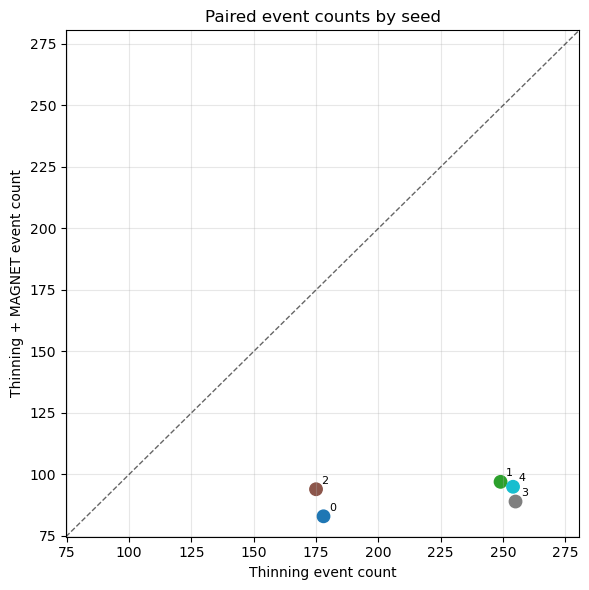

In [5]:
paired_metrics = pd.DataFrame({"seed": selected_seeds})
paired_metrics = paired_metrics.merge(
    thin_metrics.add_prefix("thinning_") if not thin_metrics.empty else pd.DataFrame(),
    left_on="seed",
    right_on="thinning_seed",
    how="left",
)
if "thinning_seed" in paired_metrics.columns:
    paired_metrics = paired_metrics.drop(columns=["thinning_seed"])

paired_metrics = paired_metrics.merge(
    mag_metrics.add_prefix("magnet_") if not mag_metrics.empty else pd.DataFrame(),
    left_on="seed",
    right_on="magnet_seed",
    how="left",
)
if "magnet_seed" in paired_metrics.columns:
    paired_metrics = paired_metrics.drop(columns=["magnet_seed"])

for prefix, catalogs in [("thinning", thin_catalogs), ("magnet", mag_catalogs)]:
    for seed in selected_seeds:
        cat = catalogs[seed]
        row_mask = paired_metrics["seed"] == seed
        col = f"{prefix}_n_events"
        if col not in paired_metrics.columns:
            paired_metrics[col] = np.nan
        paired_metrics.loc[row_mask, col] = len(cat)
        col = f"{prefix}_max_magnitude"
        if col not in paired_metrics.columns:
            paired_metrics[col] = np.nan
        paired_metrics.loc[row_mask, col] = float(cat["m"].max()) if len(cat) else np.nan
        col = f"{prefix}_median_iet_days"
        if col not in paired_metrics.columns:
            paired_metrics[col] = np.nan
        paired_metrics.loc[row_mask, col] = median_interevent_days(cat)
        if "event_source" in cat.columns:
            for sub in ("background", "triggered"):
                col = f"{prefix}_{sub}"
                if col not in paired_metrics.columns:
                    paired_metrics[col] = np.nan
                paired_metrics.loc[row_mask, col] = int((cat["event_source"] == sub).sum())

paired_metrics["delta_n"] = paired_metrics["magnet_n_events"] - paired_metrics["thinning_n_events"]
paired_metrics["magnet_over_thinning_ratio"] = (
    paired_metrics["magnet_n_events"] / paired_metrics["thinning_n_events"].replace(0, np.nan)
)
paired_metrics["thinning_bg_frac"] = paired_metrics["thinning_background"] / paired_metrics["thinning_n_events"].replace(0, np.nan)
paired_metrics["magnet_bg_frac"] = paired_metrics["magnet_background"] / paired_metrics["magnet_n_events"].replace(0, np.nan)

display(Markdown("**Paired per-realization metrics:**"))
display(paired_metrics)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    paired_metrics["thinning_n_events"],
    paired_metrics["magnet_n_events"],
    c=paired_metrics["seed"],
    cmap="tab10",
    s=80,
)
lims = [
    min(paired_metrics["thinning_n_events"].min(), paired_metrics["magnet_n_events"].min()) * 0.9,
    max(paired_metrics["thinning_n_events"].max(), paired_metrics["magnet_n_events"].max()) * 1.1,
]
ax.plot(lims, lims, "k--", lw=1.0, alpha=0.6)
for _, row in paired_metrics.iterrows():
    ax.annotate(
        int(row["seed"]),
        (row["thinning_n_events"], row["magnet_n_events"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(f"{METHOD_A_LABEL} event count")
ax.set_ylabel(f"{METHOD_B_LABEL} event count")
ax.set_title("Paired event counts by seed")
ax.grid(True, alpha=0.3)
fig.tight_layout()
show_fig(fig)


## Ensemble aggregate statistics

In [6]:
def side_by_side_aggregate(agg_a: pd.DataFrame, agg_b: pd.DataFrame, label_a: str, label_b: str) -> pd.DataFrame:
    if agg_a.empty or agg_b.empty:
        return pd.DataFrame()
    stats = ["mean", "std", "median", "min", "max"]
    rows = []
    for metric in agg_a.index:
        for stat in stats:
            if stat in agg_a.columns and stat in agg_b.columns:
                rows.append({
                    "metric": metric,
                    "statistic": stat,
                    label_a: agg_a.loc[metric, stat],
                    label_b: agg_b.loc[metric, stat],
                    f"Δ ({label_b} − {label_a})": agg_b.loc[metric, stat] - agg_a.loc[metric, stat],
                })
    return pd.DataFrame(rows)


agg_compare = side_by_side_aggregate(thin_agg, mag_agg, METHOD_A_LABEL, METHOD_B_LABEL)
display(Markdown("**Aggregate summary (from `aggregate_summary.csv`):**"))
display(agg_compare)

# Compact ensemble-level view of means only.
if not thin_agg.empty and not mag_agg.empty:
    mean_compare = pd.DataFrame({
        "metric": thin_agg.index,
        METHOD_A_LABEL: thin_agg["mean"].values,
        METHOD_B_LABEL: mag_agg["mean"].values,
    })
    mean_compare["Δ mean"] = mean_compare[METHOD_B_LABEL] - mean_compare[METHOD_A_LABEL]
    display(Markdown("**Ensemble means:**"))
    display(mean_compare)


**Aggregate summary (from `aggregate_summary.csv`):**

,metric,statistic,Thinning,Thinning + MAGNET,Δ (Thinning + MAGNET − Thinning)
0,n_events,mean,222.200000,91.600000,-130.600000
1,n_events,std,41.793540,5.639149,-36.154391
2,n_events,median,249.000000,94.000000,-155.000000
3,n_events,min,175.000000,83.000000,-92.000000
4,n_events,max,255.000000,97.000000,-158.000000
5,background,mean,65.800000,66.000000,0.200000
6,background,std,11.734564,8.916277,-2.818287
7,background,median,66.000000,67.000000,1.000000
8,background,min,48.000000,52.000000,4.000000
9,background,max,79.000000,75.000000,-4.000000


**Ensemble means:**

,metric,Thinning,Thinning + MAGNET,Δ mean
0,n_events,222.200000,91.600000,-130.600000
1,background,65.800000,66.000000,0.200000
2,triggered,156.400000,25.600000,-130.800000
3,median_dt_days,751.280656,625.581417,-125.699239
4,max_magnitude,5.979810,0.476025,-5.503786


## Tier 1 — scalar summaries

Event counts, background/triggered fractions, median interevent time, max magnitude,
cumulative N(t), and events per time bin (same Tier 1 scope as the ETAS-vs-thinning notebook).

In [7]:
meta = thin_meta or mag_meta
forecast_days = float(meta.get("forecast_days", np.nan))
if not np.isfinite(forecast_days):
    all_dt = np.concatenate([cat["dt_days"].to_numpy() for cat in list(thin_catalogs.values()) + list(mag_catalogs.values())])
    forecast_days = float(np.nanmax(all_dt)) if all_dt.size else 1.0

timewindow_start = meta.get("timewindow_start")
timewindow_end = meta.get("timewindow_end")
train_dt_days = np.array([], dtype=float)
train_days = 0.0
if timewindow_start and timewindow_end:
    ctx = load_intensity_context(thinning_dir, meta, selected_seeds[0])
    train_start_dt = pd.to_datetime(timewindow_start, utc=True).tz_convert(None)
    train_end_dt = pd.to_datetime(timewindow_end, utc=True).tz_convert(None)
    train_df = ctx["history_df"].loc[(ctx["history_df"]["time"] >= train_start_dt) & (ctx["history_df"]["time"] <= train_end_dt)]
    train_dt_days = train_df["t"].to_numpy(dtype=float) - ctx["forecast_start_t"]
    train_days = float((train_end_dt - train_start_dt).total_seconds() / 86400.0)
    mc_val = float(ctx["mc"])
else:
    mc_val = float(meta.get("mc", np.nan))

t_grid = np.linspace(-train_days, forecast_days, 200)
thin_curves = np.vstack([cumulative_on_grid(thin_catalogs[s]["dt_days"].to_numpy(), t_grid) for s in selected_seeds])
mag_curves = np.vstack([cumulative_on_grid(mag_catalogs[s]["dt_days"].to_numpy(), t_grid) for s in selected_seeds])


2026-07-08 13:12:24.445562: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-08 13:12:24.479877: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-08 13:12:24.479919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-08 13:12:24.481125: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-08 13:12:24.488192: I tensorflow/core/platform/cpu_feature_guar

2026-07-08 13:12:26,722 - INFO - GPU acceleration enabled: Compute capability 89
2026-07-08 13:12:26,724 - INFO - Loading Calculation...
2026-07-08 13:12:26,724 - INFO -   model is named NoName ETAS Model, has ID fde4667b33a3b02a
2026-07-08 13:12:26,727 - INFO -   Time Window: 
      1981-01-01 00:00:00 (aux start)
      2009-02-03 00:00:00 (start)
      2016-05-23 23:05:46 (end).
2026-07-08 13:12:26,727 - INFO -   free_productivity: False, free_background: False
2026-07-08 13:12:26,944 - INFO -   202664 out of 266662 events are within time window.
2026-07-08 13:12:26,945 - INFO -   Coordinates of region: [array([  30.8615, -122.215 ]), array([  30.8615, -113.995 ]), array([  38.541, -113.995]), array([  38.541, -122.215]), array([  30.8615, -122.215 ])]
2026-07-08 13:12:27,179 - INFO - Region has 640397.3942796533 square km
2026-07-08 13:12:27,180 - INFO - 202664 events lie within target region.
2026-07-08 13:12:27,188 - DEBUG -   Checking for rounding issues...
2026-07-08 13:12:27,18

#### Cumulative event count

2026-07-08 13:12:27,823 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=7.0.
2026-07-08 13:12:27,824 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-07-08 13:12:27,824 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-07-08 13:12:27,825 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu San

2026-07-08 13:12:27,855 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/noto/NotoTraditionalNushu-Regular.ttf', name='Noto Traditional Nushu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-07-08 13:12:27,855 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/comfortaa/Comfortaa-Regular.ttf', name='Comfortaa', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-07-08 13:12:27,855 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/opentype/fonts-hosny-amiri/Amiri-BoldSlanted.ttf', name='Amiri', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-07-08 13:12:27,856 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/roboto/unhinted/RobotoTTF/Roboto-BoldItalic.ttf', name='Roboto', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-07-08 13:12:27,85

/tmp/ipykernel_886619/3772771058.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


2026-07-08 13:12:27,979 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/opentype/urw-base35/C059-Bold.otf', name='C059', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-07-08 13:12:27,979 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/unfonts-extra/UnVada.ttf', name='UnVada', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-07-08 13:12:27,979 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/noto/NotoSansOldSouthArabian-Regular.ttf', name='Noto Sans Old South Arabian', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-07-08 13:12:27,980 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/fonts-gujr-extra/aakar-medium.ttf', name='aakar', style='normal', variant='normal', weight=500, stretch='normal', size='scalable')) = 10.145
2026-07-08 13:12:27,980 - DEBUG - findfont: score(FontE

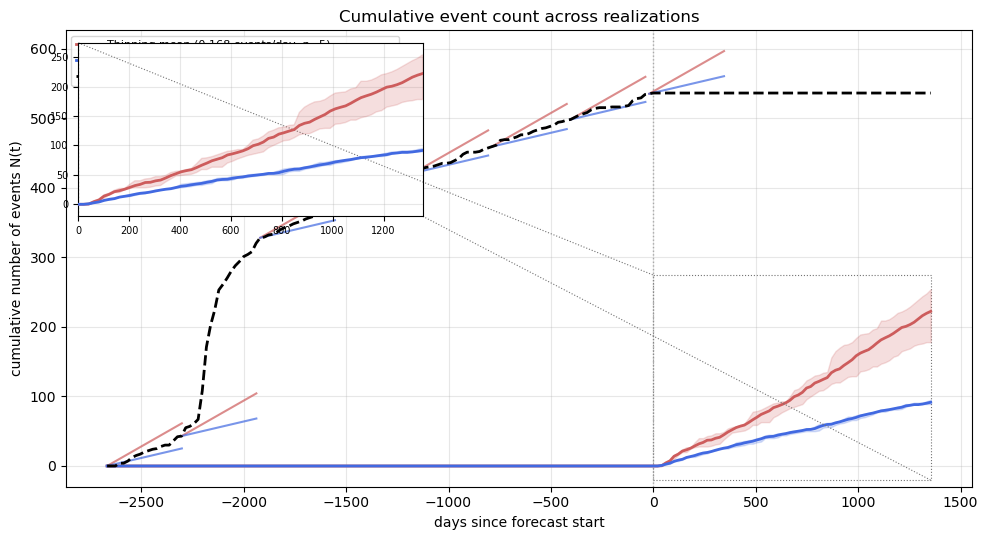

In [8]:
thin_mean = thin_curves.mean(axis=0)
mag_mean = mag_curves.mean(axis=0)
forecast_mask = t_grid >= 0.0
thin_slope = float(np.polyfit(t_grid[forecast_mask], thin_mean[forecast_mask], 1)[0])
mag_slope = float(np.polyfit(t_grid[forecast_mask], mag_mean[forecast_mask], 1)[0])

cum_ylim_curves = [thin_mean, mag_mean]
if thin_curves.shape[0] > 1:
    q25, q75 = np.quantile(thin_curves, [0.25, 0.75], axis=0)
    cum_ylim_curves.extend([q25, q75])
    q25, q75 = np.quantile(mag_curves, [0.25, 0.75], axis=0)
    cum_ylim_curves.extend([q25, q75])
cum_test_ylims = ylim_in_xrange(t_grid, cum_ylim_curves, 0.0, forecast_days)

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_cumulative_event_count(
    ax,
    t_grid=t_grid,
    curves_a=thin_curves,
    curves_b=mag_curves,
    slope_a=thin_slope,
    slope_b=mag_slope,
    train_dt_days=train_dt_days,
    train_days=train_days,
    show_training_slopes=True,
    show_legend=True,
)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("cumulative number of events N(t)")
ax.set_title("Cumulative event count across realizations")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
add_test_window_inset(
    ax,
    forecast_days,
    lambda axins: draw_cumulative_event_count(
        axins,
        t_grid=t_grid,
        curves_a=thin_curves,
        curves_b=mag_curves,
        slope_a=thin_slope,
        slope_b=mag_slope,
        train_dt_days=train_dt_days,
        train_days=train_days,
        show_training_slopes=False,
        show_legend=False,
    ),
    ylims=cum_test_ylims,
)
fig.tight_layout()
show_fig(fig)


#### Event rate by time bin

/tmp/ipykernel_886619/2574142120.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


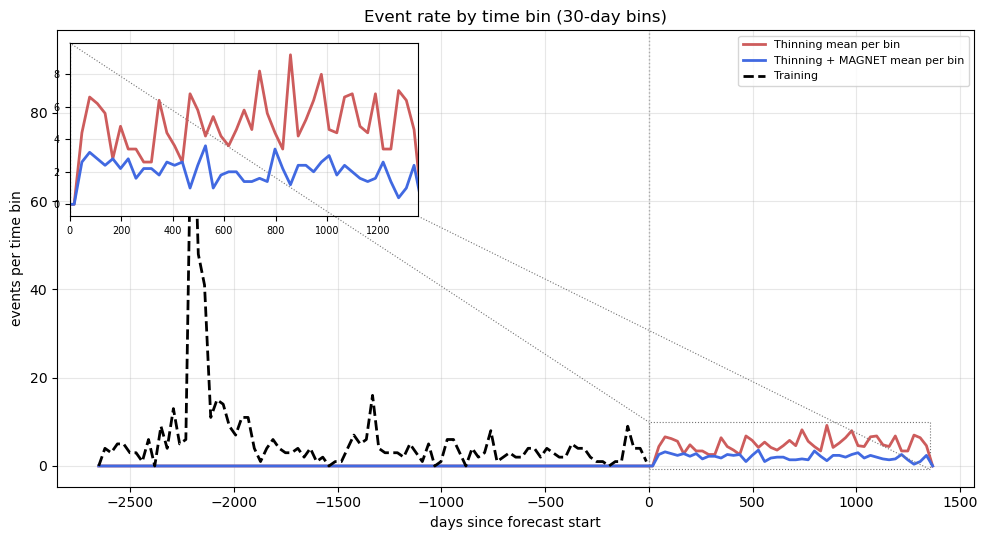

In [9]:
BIN_LENGTH_DAYS = 30.0
t_min, t_max = -train_days, forecast_days
n_bins = int(np.ceil((t_max - t_min) / BIN_LENGTH_DAYS))
bin_edges = t_min + np.arange(n_bins + 1, dtype=float) * BIN_LENGTH_DAYS
if bin_edges[-1] < t_max:
    bin_edges = np.append(bin_edges, t_max)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
thin_bin_curves = np.vstack([events_per_time_bin(thin_catalogs[s]["dt_days"].to_numpy(), bin_edges) for s in selected_seeds])
mag_bin_curves = np.vstack([events_per_time_bin(mag_catalogs[s]["dt_days"].to_numpy(), bin_edges) for s in selected_seeds])

thin_bin_mean = thin_bin_curves.mean(axis=0)
mag_bin_mean = mag_bin_curves.mean(axis=0)
bin_test_ylims = ylim_in_xrange(bin_centers, [thin_bin_mean, mag_bin_mean], 0.0, forecast_days)

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_event_rate_by_bin(
    ax,
    bin_centers=bin_centers,
    bin_edges=bin_edges,
    bin_curves_a=thin_bin_curves,
    bin_curves_b=mag_bin_curves,
    train_dt_days=train_dt_days,
    bin_length_days=BIN_LENGTH_DAYS,
    include_training=True,
    show_legend=True,
)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("events per time bin")
ax.set_title(f"Event rate by time bin ({BIN_LENGTH_DAYS:g}-day bins)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
add_test_window_inset(
    ax,
    forecast_days,
    lambda axins: draw_event_rate_by_bin(
        axins,
        bin_centers=bin_centers,
        bin_edges=bin_edges,
        bin_curves_a=thin_bin_curves,
        bin_curves_b=mag_bin_curves,
        train_dt_days=train_dt_days,
        bin_length_days=BIN_LENGTH_DAYS,
        include_training=False,
        show_legend=False,
    ),
    ylims=bin_test_ylims,
)
fig.tight_layout()
show_fig(fig)


#### Mean curve differences

**Ensemble agreement on timing curves:**

,metric,value
0,max |mean thinning − mean MAGNET| on N(t) grid,130.600000
1,mean |mean thinning − mean MAGNET| on N(t) grid,19.000000
2,max |mean thinning − mean MAGNET| per bin,8.000000
3,mean |mean thinning − mean MAGNET| per bin,0.967407


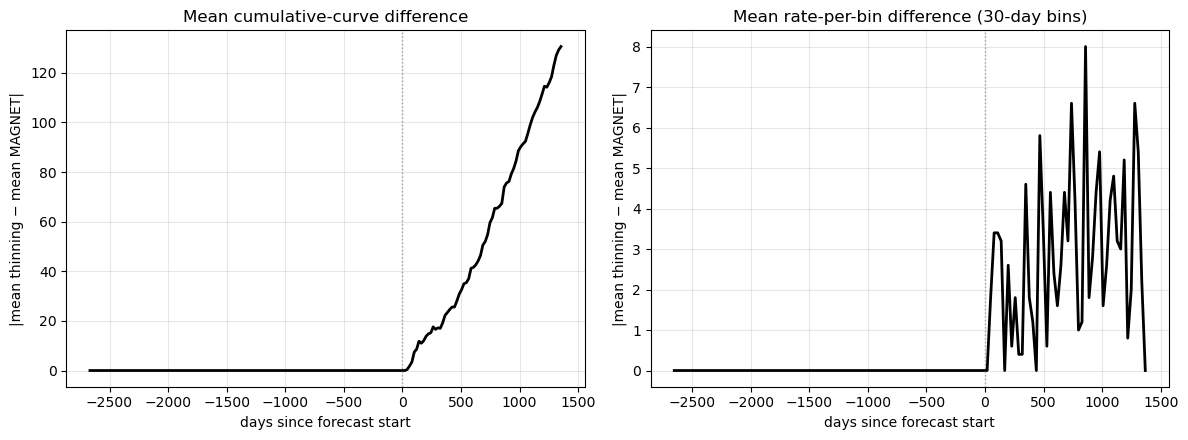

In [10]:
mean_nt_diff = np.abs(thin_curves.mean(axis=0) - mag_curves.mean(axis=0))
mean_bin_diff = np.abs(thin_bin_curves.mean(axis=0) - mag_bin_curves.mean(axis=0))
agreement_summary = pd.DataFrame({
    "metric": [
        "max |mean thinning − mean MAGNET| on N(t) grid",
        "mean |mean thinning − mean MAGNET| on N(t) grid",
        "max |mean thinning − mean MAGNET| per bin",
        "mean |mean thinning − mean MAGNET| per bin",
    ],
    "value": [float(mean_nt_diff.max()), float(mean_nt_diff.mean()), float(mean_bin_diff.max()), float(mean_bin_diff.mean())],
})
display(Markdown("**Ensemble agreement on timing curves:**"))
display(agreement_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(t_grid, mean_nt_diff, color="black", lw=2.0)
axes[0].axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7)
axes[0].set_xlabel("days since forecast start")
axes[0].set_ylabel("|mean thinning − mean MAGNET|")
axes[0].set_title("Mean cumulative-curve difference")
axes[0].grid(True, alpha=0.3)
axes[1].plot(bin_centers, mean_bin_diff, color="black", lw=2.0)
axes[1].axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7)
axes[1].set_xlabel("days since forecast start")
axes[1].set_ylabel("|mean thinning − mean MAGNET|")
axes[1].set_title(f"Mean rate-per-bin difference ({BIN_LENGTH_DAYS:g}-day bins)")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
show_fig(fig)


#### Tier 1 — boxplots and scalar summary

**Tier 1 — ensemble scalar summary:**

,metric,value
0,median MAGNET/thinning count ratio,0.389558
1,median |relative count error|,0.610442
2,median |Δ median interevent time| [days],6.465301
3,median |Δ max magnitude|,5.177944


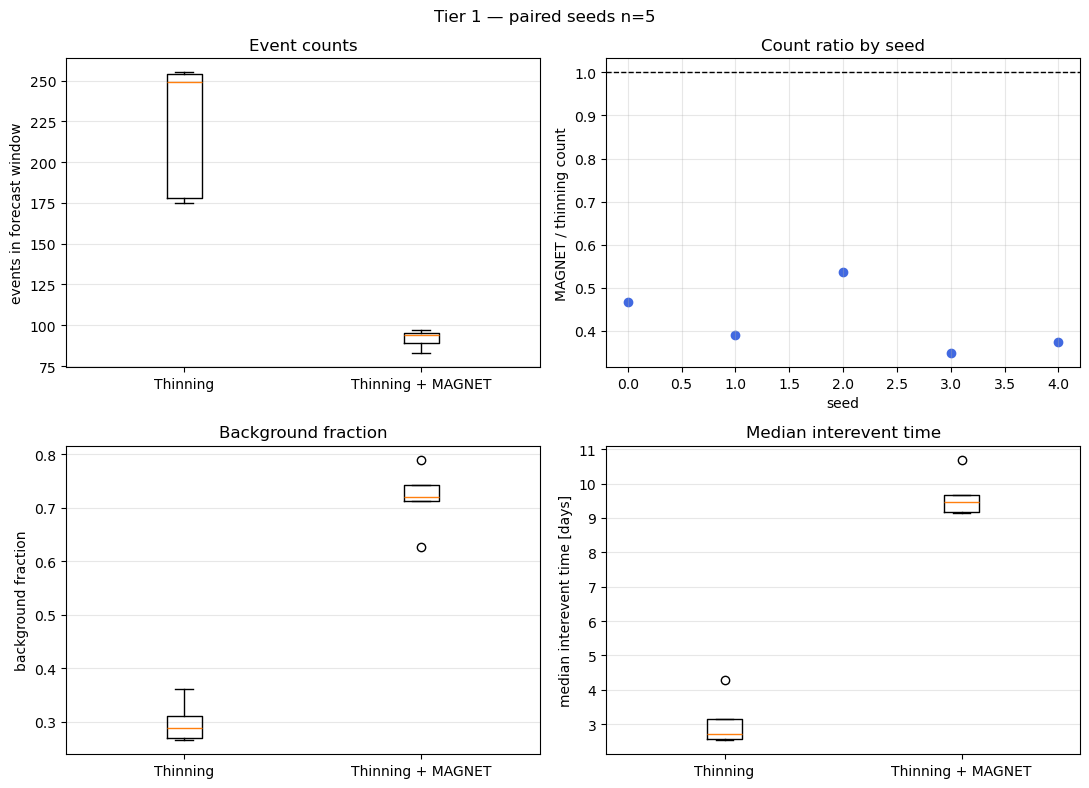

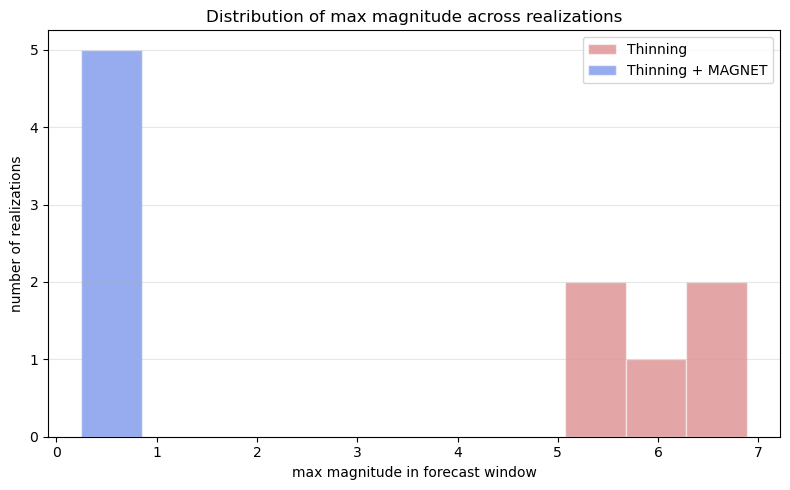

In [11]:
tier1_summary = pd.DataFrame({
    "metric": [
        "median MAGNET/thinning count ratio",
        "median |relative count error|",
        "median |Δ median interevent time| [days]",
        "median |Δ max magnitude|",
    ],
    "value": [
        float(paired_metrics["magnet_over_thinning_ratio"].median()),
        float((paired_metrics["delta_n"] / paired_metrics["thinning_n_events"].replace(0, np.nan)).abs().median()),
        float((paired_metrics["magnet_median_iet_days"] - paired_metrics["thinning_median_iet_days"]).abs().median()),
        float((paired_metrics["magnet_max_magnitude"] - paired_metrics["thinning_max_magnitude"]).abs().median()),
    ],
})
display(Markdown("**Tier 1 — ensemble scalar summary:**"))
display(tier1_summary)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].boxplot([paired_metrics["thinning_n_events"], paired_metrics["magnet_n_events"]], tick_labels=[METHOD_A_LABEL, METHOD_B_LABEL])
axes[0, 0].set_ylabel("events in forecast window")
axes[0, 0].set_title("Event counts")
axes[0, 0].grid(True, alpha=0.3, axis="y")

axes[0, 1].scatter(paired_metrics["seed"], paired_metrics["magnet_over_thinning_ratio"], color=MAGNET_COLOR)
axes[0, 1].axhline(1.0, color="black", ls="--", lw=1.0)
axes[0, 1].set_xlabel("seed")
axes[0, 1].set_ylabel("MAGNET / thinning count")
axes[0, 1].set_title("Count ratio by seed")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].boxplot([paired_metrics["thinning_bg_frac"], paired_metrics["magnet_bg_frac"]], tick_labels=[METHOD_A_LABEL, METHOD_B_LABEL])
axes[1, 0].set_ylabel("background fraction")
axes[1, 0].set_title("Background fraction")
axes[1, 0].grid(True, alpha=0.3, axis="y")

axes[1, 1].boxplot([paired_metrics["thinning_median_iet_days"], paired_metrics["magnet_median_iet_days"]], tick_labels=[METHOD_A_LABEL, METHOD_B_LABEL])
axes[1, 1].set_ylabel("median interevent time [days]")
axes[1, 1].set_title("Median interevent time")
axes[1, 1].grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Tier 1 — paired seeds n={len(selected_seeds)}", fontsize=12)
fig.tight_layout()
show_fig(fig)

m_lo = min(paired_metrics["thinning_max_magnitude"].min(), paired_metrics["magnet_max_magnitude"].min()) - 0.1
m_hi = max(paired_metrics["thinning_max_magnitude"].max(), paired_metrics["magnet_max_magnitude"].max()) + 0.1
mag_bins = np.linspace(m_lo, m_hi, 12)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(paired_metrics["thinning_max_magnitude"], bins=mag_bins, alpha=0.55, color=THINNING_COLOR, label=METHOD_A_LABEL, edgecolor="white")
ax.hist(paired_metrics["magnet_max_magnitude"], bins=mag_bins, alpha=0.55, color=MAGNET_COLOR, label=METHOD_B_LABEL, edgecolor="white")
ax.set_xlabel("max magnitude in forecast window")
ax.set_ylabel("number of realizations")
ax.set_title("Distribution of max magnitude across realizations")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
show_fig(fig)


### Tier 2 — pooled magnitude and interevent-time distributions

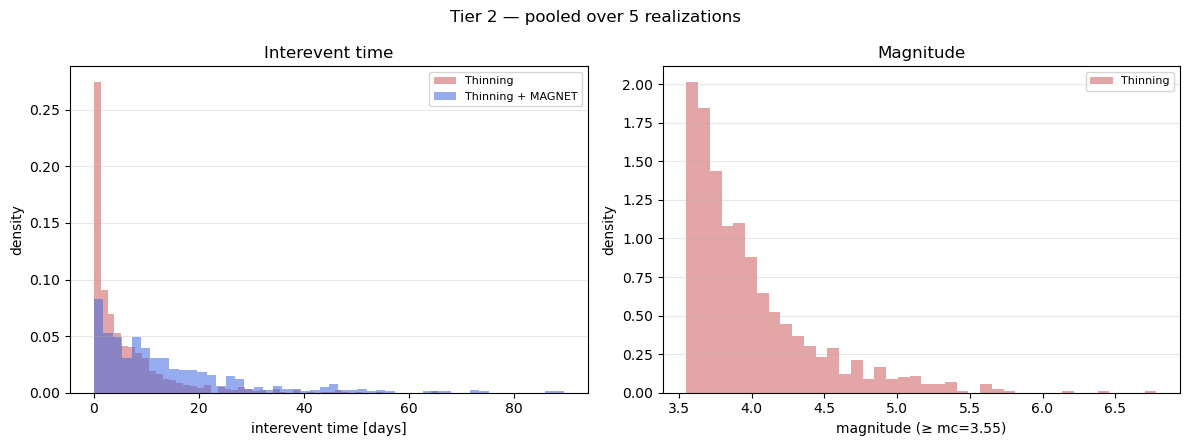

**Tier 2 — pooled KS tests:**

,comparison,KS statistic,p-value
0,interevent time,0.339515,2.175631e-33


In [12]:
thin_iet_all = np.concatenate([interevent_times(thin_catalogs[s]["dt_days"].to_numpy(dtype=float)) for s in selected_seeds])
mag_iet_all = np.concatenate([interevent_times(mag_catalogs[s]["dt_days"].to_numpy(dtype=float)) for s in selected_seeds])
thin_m_all = np.concatenate([thin_catalogs[s]["m"].to_numpy(dtype=float) for s in selected_seeds])
mag_m_all = np.concatenate([mag_catalogs[s]["m"].to_numpy(dtype=float) for s in selected_seeds])
if np.isfinite(mc_val):
    thin_m_all = thin_m_all[thin_m_all >= mc_val]
    mag_m_all = mag_m_all[mag_m_all >= mc_val]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
if thin_iet_all.size:
    axes[0].hist(thin_iet_all, bins=50, density=True, alpha=0.55, color=THINNING_COLOR, label=METHOD_A_LABEL)
if mag_iet_all.size:
    axes[0].hist(mag_iet_all, bins=50, density=True, alpha=0.55, color=MAGNET_COLOR, label=METHOD_B_LABEL)
axes[0].set_xlabel("interevent time [days]")
axes[0].set_ylabel("density")
axes[0].set_title("Interevent time")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

if thin_m_all.size:
    axes[1].hist(thin_m_all, bins=40, density=True, alpha=0.55, color=THINNING_COLOR, label=METHOD_A_LABEL)
if mag_m_all.size:
    axes[1].hist(mag_m_all, bins=40, density=True, alpha=0.55, color=MAGNET_COLOR, label=METHOD_B_LABEL)
axes[1].set_xlabel(f"magnitude (≥ mc={mc_val:.2f})" if np.isfinite(mc_val) else "magnitude")
axes[1].set_ylabel("density")
axes[1].set_title("Magnitude")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Tier 2 — pooled over {len(selected_seeds)} realizations", fontsize=12)
fig.tight_layout()
show_fig(fig)

tier2_ks = []
for name, a_data, b_data in [("interevent time", thin_iet_all, mag_iet_all), ("magnitude", thin_m_all, mag_m_all)]:
    if a_data.size and b_data.size:
        stat, pval = stats.ks_2samp(a_data, b_data)
        tier2_ks.append({"comparison": name, "KS statistic": stat, "p-value": pval})
if tier2_ks:
    display(Markdown("**Tier 2 — pooled KS tests:**"))
    display(pd.DataFrame(tier2_ks))


### Formal statistical tests (paired by seed)

In [13]:
thin_counts = paired_metrics["thinning_n_events"].to_numpy()
mag_counts = paired_metrics["magnet_n_events"].to_numpy()
paired_diff = mag_counts - thin_counts

wilcoxon_stat, wilcoxon_p = stats.wilcoxon(mag_counts, thin_counts)
pearson_r, pearson_p = stats.pearsonr(thin_counts, mag_counts)
ks_iet_stat, ks_iet_p = stats.ks_2samp(thin_iet_all, mag_iet_all)
ks_m_stat, ks_m_p = stats.ks_2samp(thin_m_all, mag_m_all)

n_perm = 5000
rng = np.random.default_rng(0)
obs_mean_diff = paired_diff.mean()
perm_diffs = np.empty(n_perm)
for i in range(n_perm):
    signs = rng.choice([-1.0, 1.0], size=len(paired_diff))
    perm_diffs[i] = (signs * paired_diff).mean()
perm_p = float((np.abs(perm_diffs) >= abs(obs_mean_diff)).mean())

formal_results = pd.DataFrame([
    {"test": "Paired Wilcoxon (counts)", "statistic": wilcoxon_stat, "p-value": wilcoxon_p},
    {"test": "Pearson r (counts)", "statistic": pearson_r, "p-value": pearson_p},
    {"test": "KS pooled interevent time", "statistic": ks_iet_stat, "p-value": ks_iet_p},
    {"test": "KS pooled magnitude (≥ mc)", "statistic": ks_m_stat, "p-value": ks_m_p},
    {"test": "Permutation mean Δcount", "statistic": obs_mean_diff, "p-value": perm_p},
])
display(Markdown("**Formal tests:**"))
display(formal_results)


/tmp/ipykernel_886619/2395574758.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_m_stat, ks_m_p = stats.ks_2samp(thin_m_all, mag_m_all)


**Formal tests:**

,test,statistic,p-value
0,Paired Wilcoxon (counts),0.000000,6.250000e-02
1,Pearson r (counts),0.460794,4.347783e-01
2,KS pooled interevent time,0.339515,2.175631e-33
3,KS pooled magnitude (≥ mc),NaN,NaN
4,Permutation mean Δcount,-130.600000,6.540000e-02
